In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [4]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [5]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 

x_train, y_train  = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)

# Defining Model

In [6]:
#model = 'XGBoost'
model = 'TabPFNClassifier'

In [7]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [8]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [9]:
x_dev

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,95,1500,0,124.16,1078.29,0.925,0.930
3,35,200,0,6.61,916.16,0.936,0.927
4,35,1500,15,54.11,1440.24,0.930,0.946
...,...,...,...,...,...,...,...
94,60,1200,0,97.26,3624.99,0.624,0.627
95,60,1200,0,97.29,4311.15,0.623,0.630
96,60,1200,0,98.26,3490.11,0.627,0.626
97,60,1200,0,98.15,3311.58,0.619,0.624


# Fit Model

In [10]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [11]:
def compute_pullforces(x, y, predictions_class):
    pullforces = []

    for sample_id, pred in zip(y.index, predictions_class):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df).iloc[0]
        else:
            value = compute_pullout_failure(row_x_df).iloc[0]

        pullforces.append(value)

    return np.array(pullforces)


In [12]:
predictions_class_train = classifier.predict(x_train)
x_train["Physical Inference"] = compute_pullforces(x_train, y_train, predictions_class_train)


predictions_class_dev = classifier.predict(x_dev)
x_dev["Physical Inference"] = compute_pullforces(x_dev, y_dev, predictions_class_dev)


In [13]:
x_train.head()

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm),Physical Inference
0,35,200,0,6.82,1081.47,0.922,0.920,2953.9
1,35,1500,0,52.25,2014.73,0.920,0.925,5988.6
2,95,200,0,16.57,1321.93,0.912,0.924,2928.2
3,95,200,0,41.42,1615.83,0.948,0.939,3014.9
4,35,1500,0,63.82,1137.29,0.930,0.937,6097.2


In [14]:
print(predictions_class_dev)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [15]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()

In [16]:
y_train_Regressor.head(10)

Sample ID
1     2127.7
2     5346.4
4     2350.4
5     2174.8
7     3897.5
9     1932.5
11    3816.0
12    1832.5
15    5634.8
17    2685.9
Name: PullTest (N), dtype: float64

In [17]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm),Physical Inference
0,35,200,0,6.82,1081.47,0.922,0.920,2953.9
1,35,1500,0,52.25,2014.73,0.920,0.925,5988.6
2,95,200,0,16.57,1321.93,0.912,0.924,2928.2
3,95,200,0,41.42,1615.83,0.948,0.939,3014.9
4,35,1500,0,63.82,1137.29,0.930,0.937,6097.2
...,...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622,3137.3
291,60,1200,0,97.32,2636.69,0.622,0.632,3137.3
292,60,1200,0,98.07,3601.67,0.666,0.633,3228.9
293,60,1200,0,97.09,4161.74,0.615,0.619,3079.6


# Fit 2nd Model

In [18]:
regressor = TabPFNRegressor()
regressor.fit(x_train, y_train_Regressor)

# Predict on the test set
predictions_regression_dev = regressor.predict(x_dev)


In [19]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [20]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=predictions_regression_dev,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [21]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, predictions_regression_dev)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, predictions_regression_dev))
R2   = r2_score(y_dev_Regressor, predictions_regression_dev)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  127.34
RMSE: 224.55
R2: 0.60


# Define Model

In [50]:
#model_name_class = 'XGBoostClassifier'
#model_name_class = 'RandomForestClassifier'
model_name_class = 'TabPFNClassifier'

#model_name_reg = 'XGBoost'
#model_name_reg = 'RandomForest'
model_name_reg = 'TabPFN'


# Cross Validation


Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
192        235              60                400            0      92.76   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
192       3707.1             0.628             0.634  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
192        2616.7                 3.07      Bad      NaN  


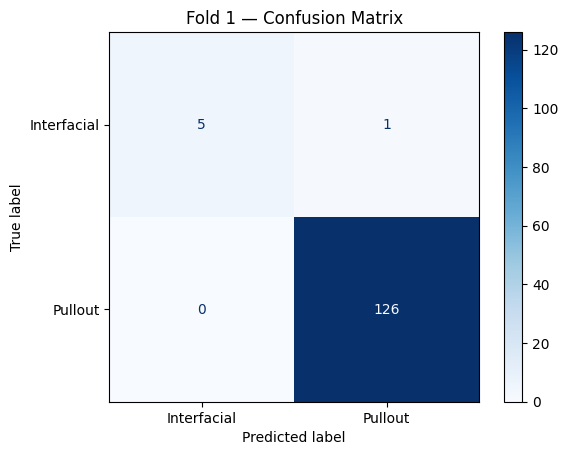

F1 Score: 0.9525691699604744



=== Fold 1 ===
Direct:
 MAE=135.18,
 RMSE=236.61,
 R²=0.61

Hybrid:
 MAE=135.30,
 RMSE=237.27,
 R²=0.61

Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
384        480              60               1200            0      98.49   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
384      2308.35             0.624             0.626  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
384        1410.3                  1.9      Bad      NaN  


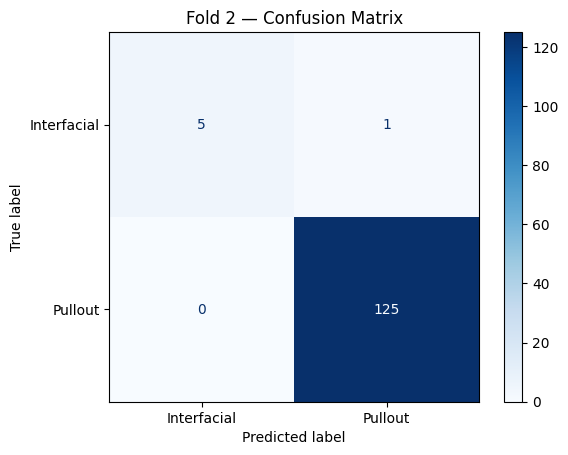

F1 Score: 0.9525534226729446



=== Fold 2 ===
Direct:
 MAE=134.05,
 RMSE=260.95,
 R²=0.69

Hybrid:
 MAE=134.11,
 RMSE=261.20,
 R²=0.69

Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
154        189              60                400            0      91.17   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
154       3119.0              0.64             0.633  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
154        2634.6                  2.7      Bad      NaN  


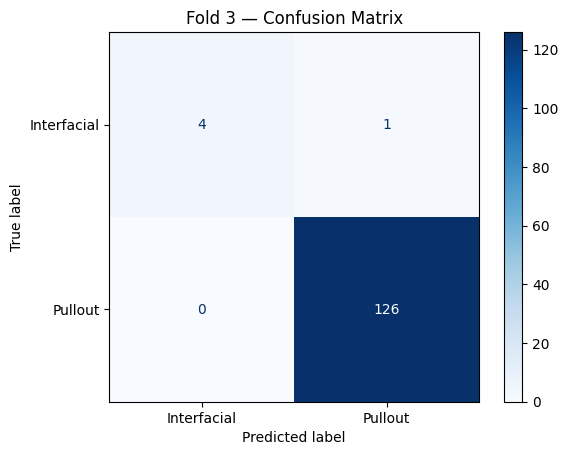

F1 Score: 0.9424681598594642



=== Fold 3 ===
Direct:
 MAE=132.30,
 RMSE=216.10,
 R²=0.68

Hybrid:
 MAE=130.90,
 RMSE=211.35,
 R²=0.70

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
mean MAE:  133.84 ± 1.19
mean RMSE: 237.89 ± 18.33
mean R²:   0.66 ± 0.03

--- Hybrid Model ---
mean MAE:  133.44 ± 1.86
mean RMSE: 236.61 ± 20.36
mean R²:   0.66 ± 0.04


In [52]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mapping = {
    "Explode": "Pullout",
    "Good": "Pullout",
    "Bad": "Interfacial"
}

def apply_mapping(arr):
    return np.array([mapping[x] for x in arr])

#Metrics with and without physical inference
direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):


    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    train_df["Category"] = apply_mapping(train_df["Category"])
    val_df["Category"] = apply_mapping(val_df["Category"])

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    # -----------------------------
    # XGBoost CLASSIFIER
    # -----------------------------
    if model_name_class == 'XGBoostClassifier':

        params = {
            "max_depth": 5,
            "learning_rate": 0.3,
            "n_estimators": 177,
            "tree_method": "hist",
            "eval_metric": "mlogloss"
        }

        # Encode labels → integers (required for XGBClassifier)
        le = LabelEncoder()
        y_val_class = le.fit_transform(y_val_class)
        y_tr_class = le.transform(y_tr_class)

        classifier = XGBClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)
        # Reverse LabelEncoder back to original class names
        preds = le.inverse_transform(preds)
        y_val_class = le.inverse_transform(y_val_class)


    # -----------------------------
    # RANDOM FOREST CLASSIFIER
    # -----------------------------
    elif model_name_class == 'RandomForestClassifier':

        
        params = {
            'n_estimators': 27,
            'max_depth': 7,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'log2',
        }

        classifier = RandomForestClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

    # -----------------------------
    # TABPFN CLASSIFIER
    # -----------------------------
    elif model_name_class == 'TabPFNClassifier':

        classifier = TabPFNClassifier()
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

    mis_idx = np.where(preds != y_val_class)[0]

    if len(mis_idx) > 0:
        mis_sample_ids = x_val_class.index[mis_idx]   # correct index space
        print("\nMisclassified rows:")
        print(cross_df[cross_df["Sample ID"].isin(mis_sample_ids)])


    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=preds,
        class_labels=["Interfacial", "Pullout"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

    
    if model_name_reg == 'TabPFN':

        # Initialize the regressor
        regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
        # To use TabPFN v2:
        # regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)
        regressor.fit(x_tr_reg, y_tr_reg)

        # Predict on the test set
        predictions_regression_dev_without_physics = regressor.predict(x_val_reg)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)




    elif model_name_reg == 'XGBoost':

        # Convert the data into DMatrix format
        dtrain = xgb.DMatrix(x_tr_reg, label=y_train)
        dtest = xgb.DMatrix(x_val_reg, label=y_val_reg)

        # Set the parameters for the XGBoost model
        params = {
            'objective': 'reg:squarederror',
            'max_depth': 1,
            'eta': 0.57,
            'eval_metric': 'rmse',
        }

        # Train the model
        num_boost_round = 13
        bst = xgb.train(params, dtrain, num_boost_round)

        # Make predictions
        predictions_regression_dev_without_physics = bst.predict(dtest)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)


    elif model_name_reg == 'RandomForest':

        # Set the parameters for the Random Forest model
        params = {
                'n_estimators': 19,
                'max_depth': 5,
                'min_samples_split': 6,
                'min_samples_leaf': 3,
                'random_state': 42,
        }

        predictions_regression_dev_without_physics = RandomForestRegressor(**params).fit(x_tr_reg, y_tr_reg).predict(x_val_reg)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)



    direct_mae.append(mean_absolute_error(y_val_reg, predictions_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, predictions_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, predictions_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=predictions_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction ({model_name_reg}) by Category"
    )

    x_tr_hybrid = x_tr_reg.copy() 
    x_val_hybrid = x_val_reg.copy() 

    physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train) 
    physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev)

    x_tr_hybrid["Physical_Inference"] = physics_train 
    x_val_hybrid["Physical_Inference"] = physics_val 
    
    hybrid_model = TabPFNRegressor() 
    hybrid_model.fit(x_tr_hybrid, y_train_reg) 
    
    hybrid_pred = hybrid_model.predict(x_val_hybrid) 
    hybrid_mae.append(mean_absolute_error(y_val_reg, hybrid_pred)) 
    hybrid_rmse.append(np.sqrt(mean_squared_error(y_val_reg, hybrid_pred))) 
    hybrid_r2.append(r2_score(y_val_reg, hybrid_pred))  

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=hybrid_pred,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction ({model_name_reg}) by Category with Physical Inference"
    )

    print(f"\n=== Fold {fold+1} ===") 
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")
    print(f"Hybrid:\n MAE={hybrid_mae[-1]:.2f},\n RMSE={hybrid_rmse[-1]:.2f},\n R²={hybrid_r2[-1]:.2f}")


print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"mean MAE:  {np.mean(direct_mae):.2f} ± {np.std(direct_mae):.2f}")
print(f"mean RMSE: {np.mean(direct_rmse):.2f} ± {np.std(direct_rmse):.2f}")
print(f"mean R²:   {np.mean(direct_r2):.2f} ± {np.std(direct_r2):.2f}")

print("\n--- Hybrid Model ---") 
print(f"mean MAE:  {np.mean(hybrid_mae):.2f} ± {np.std(hybrid_mae):.2f}")
print(f"mean RMSE: {np.mean(hybrid_rmse):.2f} ± {np.std(hybrid_rmse):.2f}")
print(f"mean R²:   {np.mean(hybrid_r2):.2f} ± {np.std(hybrid_r2):.2f}")